# EMG Dry Run — Signal Quality Check
**File:** `Sizetest.bin`  
**Setup:** Ch 0 = Rectus Femoris, Ch 1 = Tibialis Anterior, Ch 2–3 = unconnected  
**Sampling rate:** 500 Hz (SAMPLE_PERIOD_US = 2000 µs, confirmed from firmware)  
**Duration:** ~34 s, 17108 samples  
**Notes:** No leg shave, no exoskeleton worn, IMU connected but handheld. Standing + voluntary flexing + squats.

In [2]:
import struct
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

# ── Binary decoder ──────────────────────────────────────────────
# Format: 4-byte DEADBEEF header, 45-byte records, 4-byte BEEFDEAD footer
# Record struct (little-endian, packed):
#   uint32  timestamp       (ms * 2? or custom tick)
#   uint16  adc[4]          EMG channels (12-bit ADC, 0–4095)
#   int16   imu[10]         accel(3) + gyro(3) + mag(3) + temp(1)
#   int16   leftMotor[3]    angle, velocity, torque
#   int16   rightMotor[3]   angle, velocity, torque
#   int8    mode            knob switch

HEADER_SIZE = 4
FOOTER_SIZE = 4
RECORD_SIZE = 45
RECORD_FMT = '<I 4H 10h 3h 3h b'

def load_bin(filepath):
    with open(filepath, 'rb') as f:
        data = f.read()
    
    magic = struct.unpack('<I', data[:4])[0]
    assert magic == 0xDEADBEEF, f'Bad magic: 0x{magic:08X}'
    
    n_records = (len(data) - HEADER_SIZE - FOOTER_SIZE) // RECORD_SIZE
    
    timestamps = np.zeros(n_records, dtype=np.uint32)
    emg = np.zeros((n_records, 4), dtype=np.uint16)
    imu = np.zeros((n_records, 10), dtype=np.int16)
    left_motor = np.zeros((n_records, 3), dtype=np.int16)
    right_motor = np.zeros((n_records, 3), dtype=np.int16)
    mode = np.zeros(n_records, dtype=np.int8)
    
    for i in range(n_records):
        offset = HEADER_SIZE + i * RECORD_SIZE
        rec = struct.unpack(RECORD_FMT, data[offset:offset+RECORD_SIZE])
        timestamps[i] = rec[0]
        emg[i] = rec[1:5]
        imu[i] = rec[5:15]
        left_motor[i] = rec[15:18]
        right_motor[i] = rec[18:21]
        mode[i] = rec[21]
    
    return timestamps, emg, imu, left_motor, right_motor, mode

timestamps, emg, imu, left_motor, right_motor, mode = load_bin('./data/wawa/Sizetest.bin')

# Derive time axis
dt = np.median(np.diff(timestamps))  # 2 ms per sample
fs = 500  # Hz (confirmed: SAMPLE_PERIOD_US = 2000 µs)
t = (timestamps - timestamps[0]) / 1000  # convert ms to seconds

print(f'Records: {len(timestamps)}')
print(f'Duration: {t[-1]:.2f} s')
print(f'Timestamp delta: {dt} ms → {fs} Hz')
print(f'Mode values: {np.unique(mode)}')

# Preview first 5 decoded records
print(f'\n── First 5 records ──')
print(f'{"Rec":<5} {"ts (ms)":<10} {"EMG[0:4]":<28} {"Acc XYZ":<24} {"Gyro XYZ":<24} {"Mode":<5}')
print('-' * 100)
for i in range(5):
    print(f'{i:<5} {timestamps[i]:<10} {str(emg[i]):<28} {str(imu[i,:3]):<24} {str(imu[i,3:6]):<24} {mode[i]:<5}')

Records: 17108
Duration: 34.21 s
Timestamp delta: 2.0 ms → 500 Hz
Mode values: [0]

── First 5 records ──
Rec   ts (ms)    EMG[0:4]                     Acc XYZ                  Gyro XYZ                 Mode 
----------------------------------------------------------------------------------------------------
0     1760       [ 244  439 1053  603]        [ -216 13744 -9008]      [-292  368   58]         0    
1     1762       [ 243  444 1053  597]        [ -176 13656 -8616]      [ -23 -122  353]         0    
2     1764       [ 239  438 1049  595]        [   96 13560 -8728]      [ 117 -188  225]         0    
3     1766       [ 239  434 1078  611]        [ -112 13592 -8584]      [-527 -384 -343]         0    
4     1768       [ 233  435 1069  603]        [  -64 13480 -8736]      [318 293 -68]            0    


## 1. Raw EMG — Time Domain

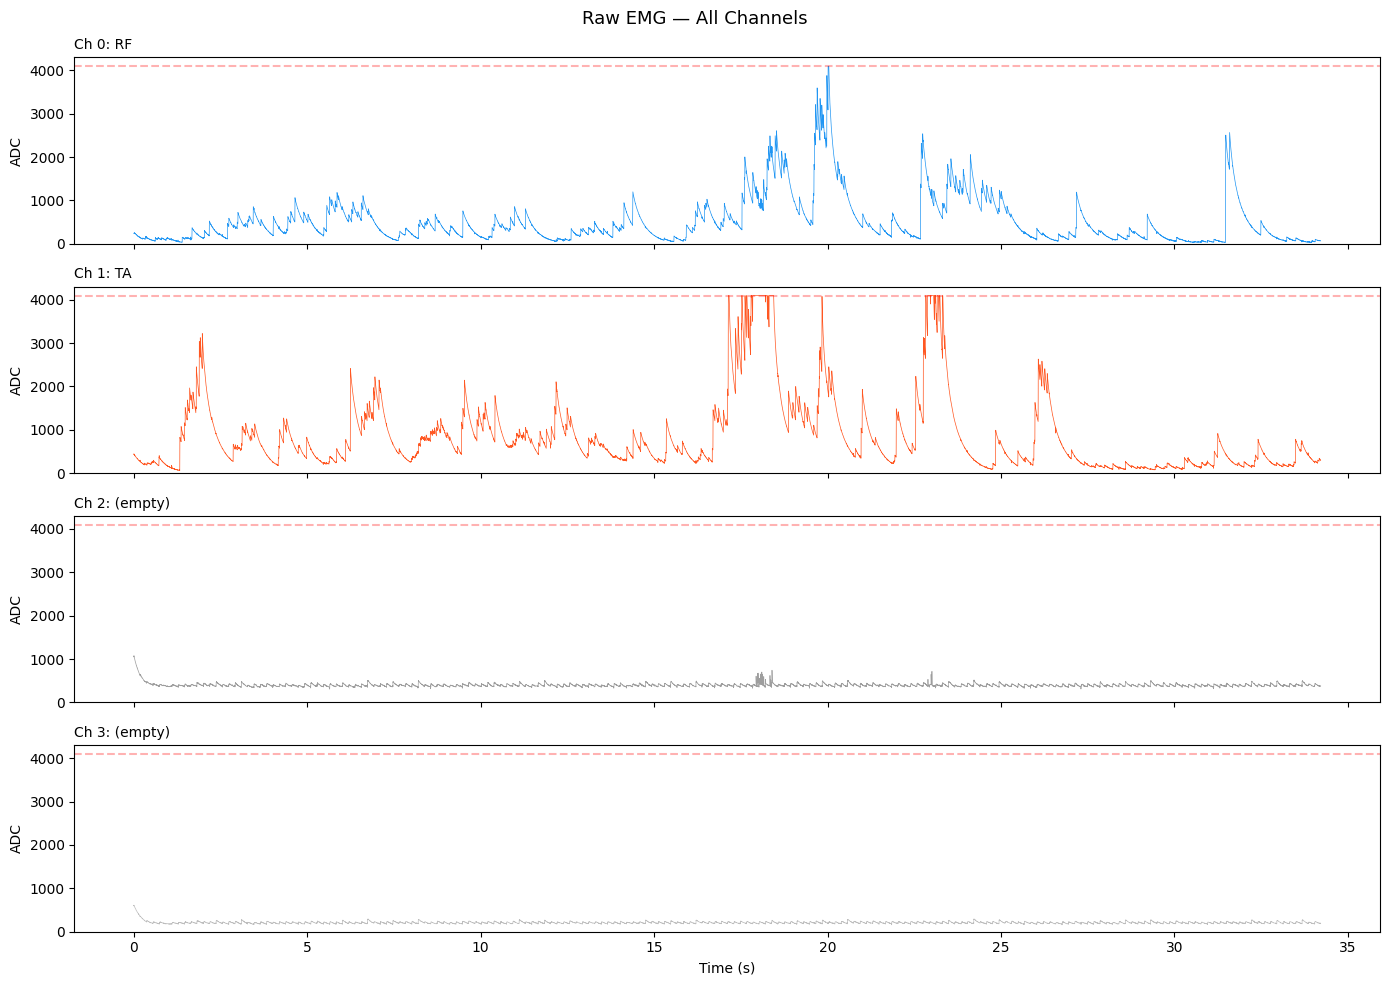

Channel                 Min    Max     Mean      Std  Saturated
------------------------------------------------------------
Ch 0: RF                 29   4095    521.4    544.2    12/17108 (0.1%)
Ch 1: TA                 58   4095    869.5    880.8   456/17108 (2.7%)
Ch 2: (empty)           307   1078    400.4     45.5     0/17108 (0.0%)
Ch 3: (empty)           158    611    211.3     28.4     0/17108 (0.0%)


In [3]:
ch_labels = ['Ch 0: RF', 'Ch 1: TA', 'Ch 2: (empty)', 'Ch 3: (empty)']
ch_colors = ['#2196F3', '#FF5722', '#9E9E9E', '#BDBDBD']

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i in range(4):
    axes[i].plot(t, emg[:, i], color=ch_colors[i], linewidth=0.5)
    axes[i].set_ylabel('ADC')
    axes[i].set_title(ch_labels[i], fontsize=10, loc='left')
    axes[i].axhline(4095, color='red', linestyle='--', alpha=0.3, label='ADC max')
    axes[i].set_ylim(0, 4300)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Raw EMG — All Channels', fontsize=13)
plt.tight_layout()
plt.show()

# Stats table
print(f'{"Channel":<20} {"Min":>6} {"Max":>6} {"Mean":>8} {"Std":>8} {"Saturated":>10}')
print('-' * 60)
for i in range(4):
    sat = np.sum(emg[:, i] == 4095)
    print(f'{ch_labels[i]:<20} {emg[:,i].min():>6} {emg[:,i].max():>6} '
          f'{emg[:,i].mean():>8.1f} {emg[:,i].std():>8.1f} {sat:>5}/{len(emg)} ({100*sat/len(emg):.1f}%)')

## 2. EMG Preprocessing — Bandpass + Rectify + Envelope
Standard EMG pipeline: 20–450 Hz bandpass → full-wave rectify → 6 Hz lowpass envelope

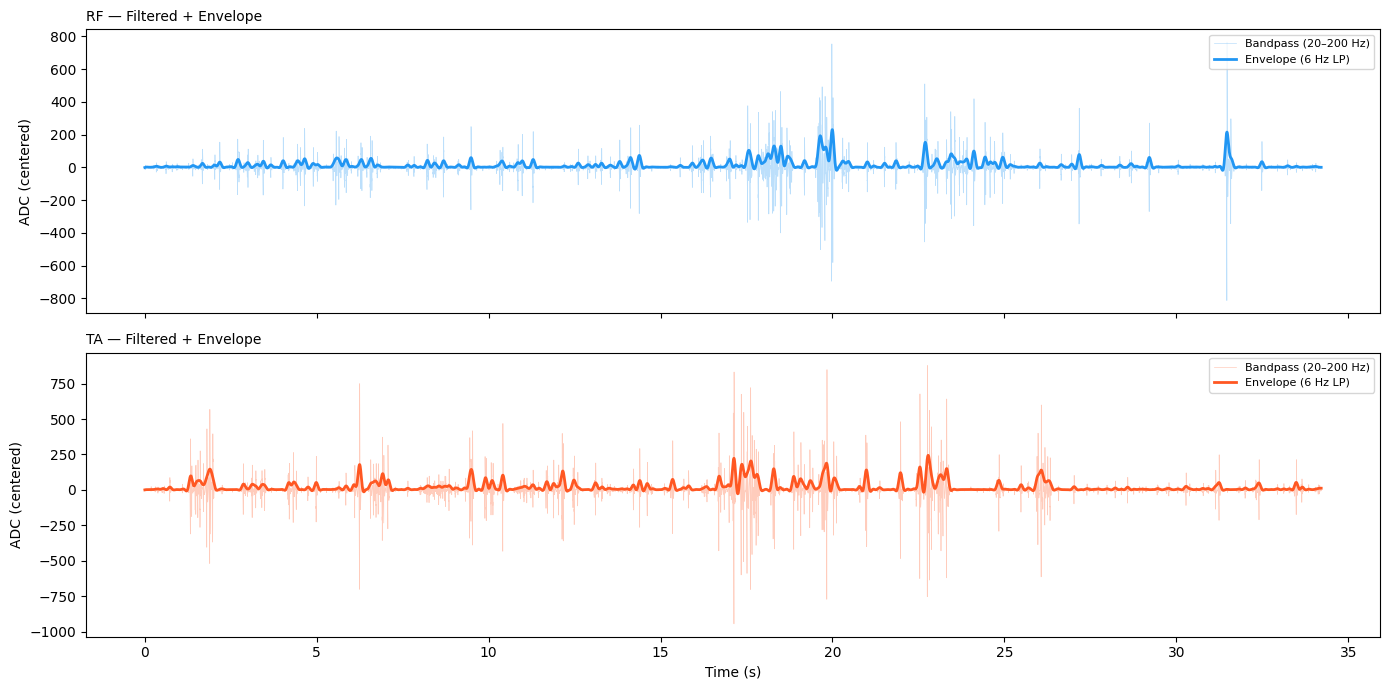

In [4]:
def emg_envelope(raw, fs, bp_low=20, bp_high=200, env_cutoff=6):
    """Bandpass → rectify → lowpass envelope.
    bp_high capped at Nyquist-safe value for fs=500 Hz."""
    nyq = fs / 2
    bp_high = min(bp_high, nyq - 1)
    
    # Remove DC
    centered = raw - np.mean(raw)
    
    # Bandpass
    sos_bp = signal.butter(4, [bp_low / nyq, bp_high / nyq], btype='band', output='sos')
    filtered = signal.sosfiltfilt(sos_bp, centered)
    
    # Full-wave rectify
    rectified = np.abs(filtered)
    
    # Lowpass envelope
    sos_lp = signal.butter(4, env_cutoff / nyq, btype='low', output='sos')
    envelope = signal.sosfiltfilt(sos_lp, rectified)
    
    return centered, filtered, rectified, envelope

# Process connected channels only
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for idx, (ch, label, color) in enumerate([(0, 'RF', '#2196F3'), (1, 'TA', '#FF5722')]):
    raw = emg[:, ch].astype(float)
    centered, filt, rect, env = emg_envelope(raw, fs)
    
    axes[idx].plot(t, filt, color=color, alpha=0.3, linewidth=0.5, label='Bandpass (20–200 Hz)')
    axes[idx].plot(t, env, color=color, linewidth=2, label='Envelope (6 Hz LP)')
    axes[idx].set_ylabel('ADC (centered)')
    axes[idx].set_title(f'{label} — Filtered + Envelope', fontsize=10, loc='left')
    axes[idx].legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## 3. Frequency Spectrum (FFT)
Check for: EMG band (20–200 Hz), 50 Hz power line noise, motion artifact (<10 Hz)

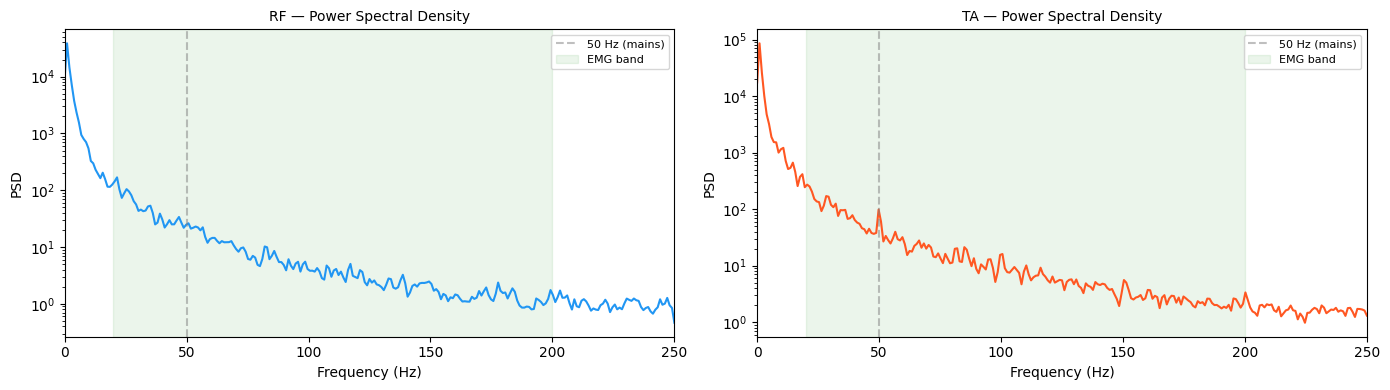

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for idx, (ch, label, color) in enumerate([(0, 'RF', '#2196F3'), (1, 'TA', '#FF5722')]):
    raw = emg[:, ch].astype(float) - emg[:, ch].mean()
    freqs, psd = signal.welch(raw, fs=fs, nperseg=min(512, len(raw)), noverlap=256)
    
    axes[idx].semilogy(freqs, psd, color=color)
    axes[idx].axvline(50, color='gray', linestyle='--', alpha=0.5, label='50 Hz (mains)')
    axes[idx].axvspan(20, 200, alpha=0.08, color='green', label='EMG band')
    axes[idx].set_xlabel('Frequency (Hz)')
    axes[idx].set_ylabel('PSD')
    axes[idx].set_title(f'{label} — Power Spectral Density', fontsize=10)
    axes[idx].legend(fontsize=8)
    axes[idx].set_xlim(0, fs/2)

plt.tight_layout()
plt.show()

## 4. SNR Estimate
Compare active vs. quiet segments. Since this is a short walking-around recording,  
we use the envelope to find high-activity (top 25%) vs. low-activity (bottom 25%) windows.

In [6]:
print(f'{"Channel":<8} {"Noise floor (Q25 RMS)":>22} {"Signal (Q75 RMS)":>20} {"SNR (dB)":>10}')
print('-' * 65)

for ch, label in [(0, 'RF'), (1, 'TA')]:
    raw = emg[:, ch].astype(float)
    _, filt, _, env = emg_envelope(raw, fs)
    
    q25 = np.percentile(env, 25)
    q75 = np.percentile(env, 75)
    
    quiet_mask = env <= q25
    active_mask = env >= q75
    
    noise_rms = np.sqrt(np.mean(filt[quiet_mask] ** 2))
    signal_rms = np.sqrt(np.mean(filt[active_mask] ** 2))
    
    snr_db = 20 * np.log10(signal_rms / noise_rms) if noise_rms > 0 else float('inf')
    
    print(f'{label:<8} {noise_rms:>22.1f} {signal_rms:>20.1f} {snr_db:>10.1f}')

Channel   Noise floor (Q25 RMS)     Signal (Q75 RMS)   SNR (dB)
-----------------------------------------------------------------
RF                          2.9                 89.1       29.7
TA                          4.0                125.9       30.0


## 5. Stomp Detection Test
Look for high-amplitude transients that could serve as segmentation markers.

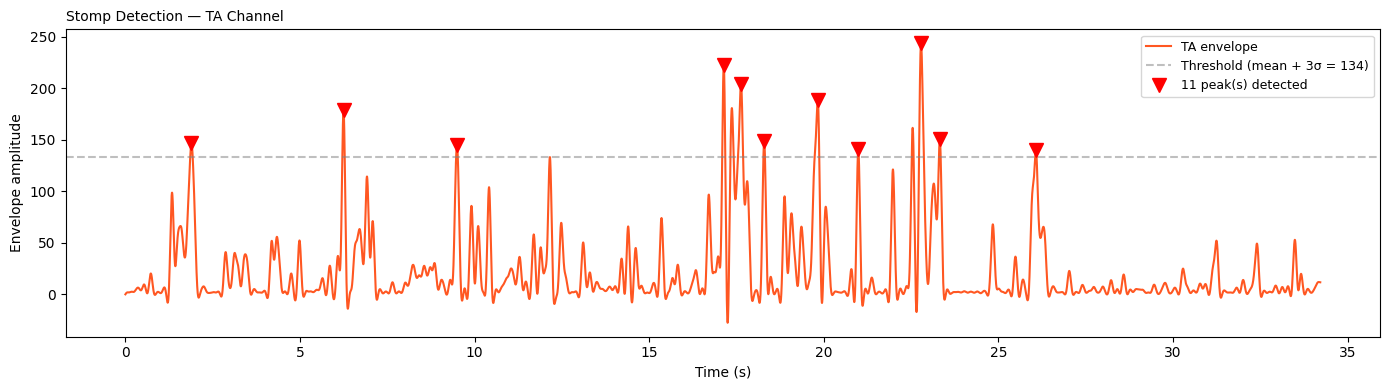

Detected peaks:
  t = 1.892 s, amplitude = 147
  t = 6.246 s, amplitude = 179
  t = 9.494 s, amplitude = 145
  t = 17.134 s, amplitude = 223
  t = 17.628 s, amplitude = 204
  t = 18.292 s, amplitude = 149
  t = 19.826 s, amplitude = 188
  t = 20.986 s, amplitude = 141
  t = 22.784 s, amplitude = 244
  t = 23.320 s, amplitude = 150
  t = 26.072 s, amplitude = 140


In [7]:
# Use TA (Ch 1) — most responsive to stomps (dorsiflexor fires on foot strike)
raw_ta = emg[:, 1].astype(float)
_, filt_ta, _, env_ta = emg_envelope(raw_ta, fs)

# Find peaks in envelope above threshold
threshold = np.mean(env_ta) + 3 * np.std(env_ta)
peaks, props = signal.find_peaks(env_ta, height=threshold, distance=int(0.3 * fs))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, env_ta, color='#FF5722', linewidth=1.5, label='TA envelope')
ax.axhline(threshold, color='gray', linestyle='--', alpha=0.5, label=f'Threshold (mean + 3σ = {threshold:.0f})')
if len(peaks) > 0:
    ax.plot(t[peaks], env_ta[peaks], 'v', color='red', markersize=10, label=f'{len(peaks)} peak(s) detected')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Envelope amplitude')
ax.set_title('Stomp Detection — TA Channel', fontsize=10, loc='left')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

if len(peaks) > 0:
    print('Detected peaks:')
    for p in peaks:
        print(f'  t = {t[p]:.3f} s, amplitude = {env_ta[p]:.0f}')
else:
    print('No clear stomp-like transients detected (expected — this was casual walking, not a stomp test).')

## 6. Connected vs. Unconnected Channels
Ch 2 & 3 should show only noise (no EMG pattern). If they look similar to Ch 0 & 1, something's wrong.

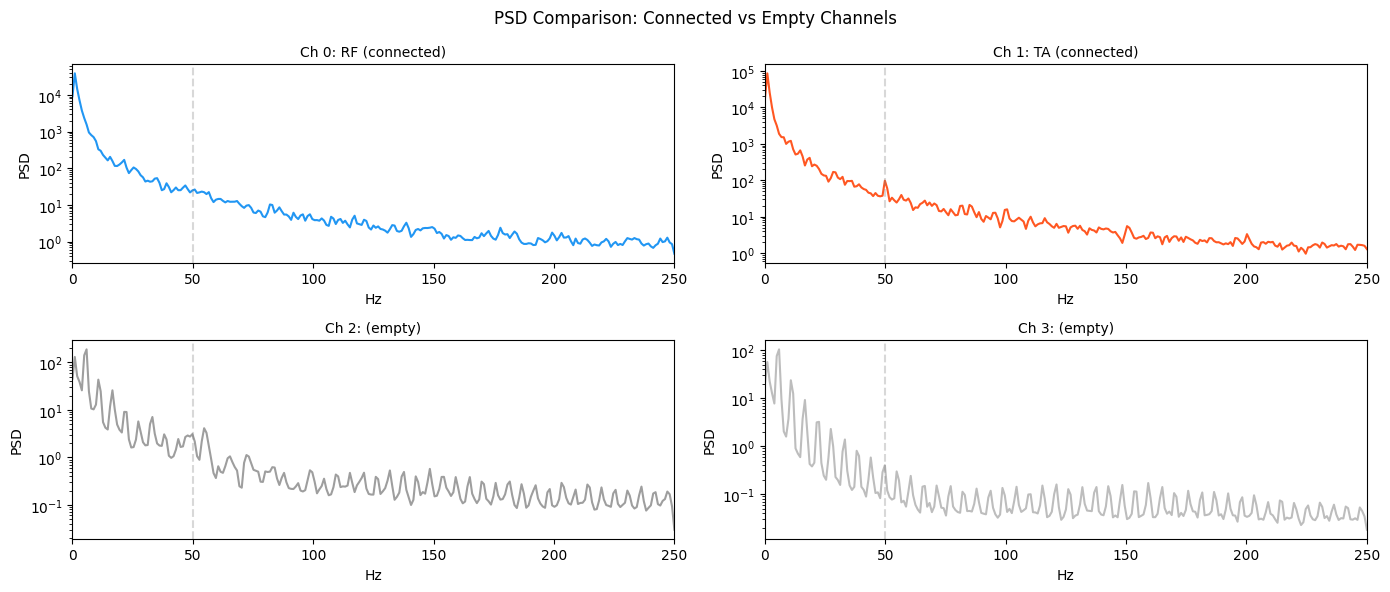

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 6))

for idx, (ch, label) in enumerate([(0, 'Ch 0: RF (connected)'), (1, 'Ch 1: TA (connected)'),
                                    (2, 'Ch 2: (empty)'), (3, 'Ch 3: (empty)')]):
    row, col = idx // 2, idx % 2
    raw = emg[:, ch].astype(float) - emg[:, ch].mean()
    freqs, psd = signal.welch(raw, fs=fs, nperseg=min(512, len(raw)), noverlap=256)
    
    axes[row][col].semilogy(freqs, psd, color=ch_colors[ch])
    axes[row][col].axvline(50, color='gray', linestyle='--', alpha=0.3)
    axes[row][col].set_title(label, fontsize=10)
    axes[row][col].set_xlabel('Hz')
    axes[row][col].set_ylabel('PSD')
    axes[row][col].set_xlim(0, fs/2)

plt.suptitle('PSD Comparison: Connected vs Empty Channels', fontsize=12)
plt.tight_layout()
plt.show()

## 7. IMU Quick Look
IMU was handheld so data is meaningless for gait — just verify the channels are logging.

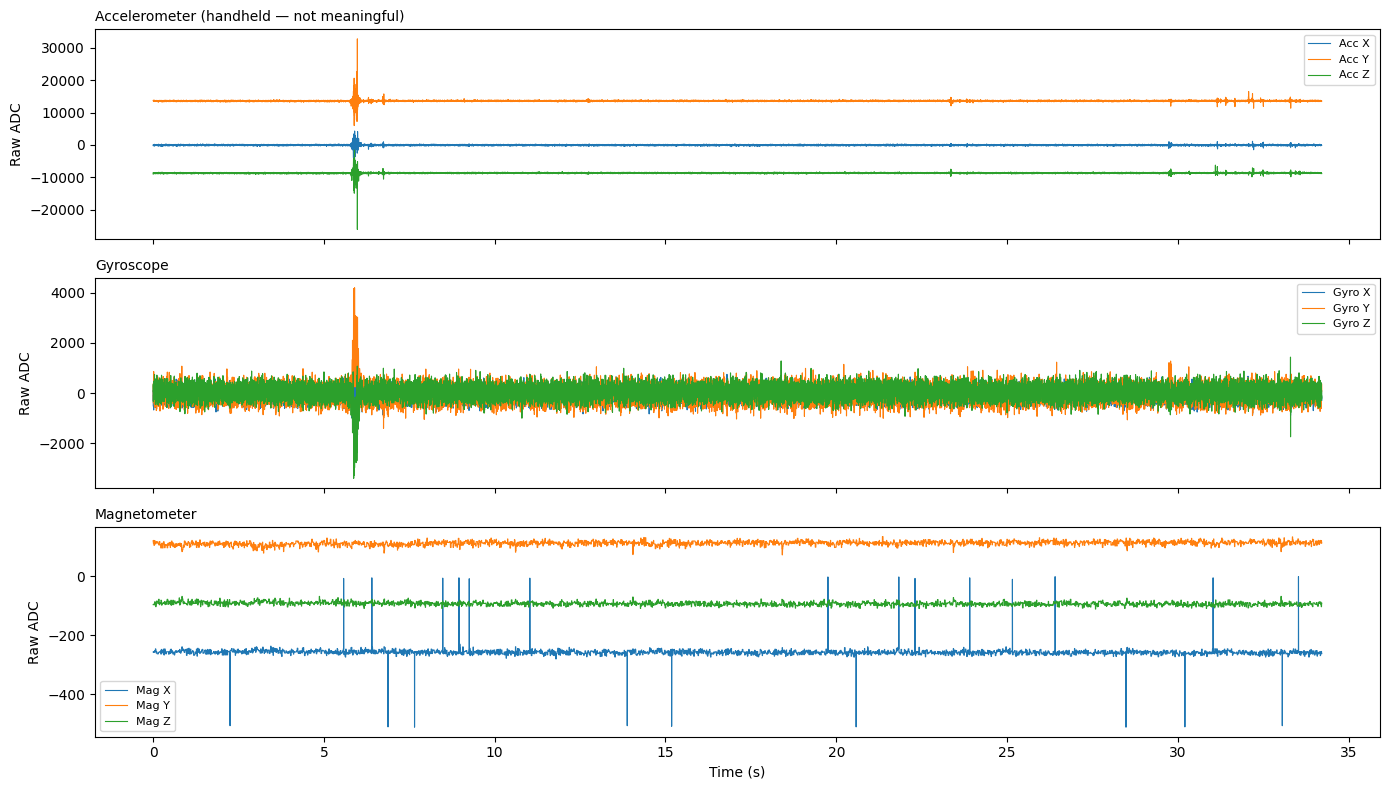

IMU channels are logging ✓


In [9]:
imu_labels = ['Acc X', 'Acc Y', 'Acc Z', 'Gyro X', 'Gyro Y', 'Gyro Z',
              'Mag X', 'Mag Y', 'Mag Z', 'Temp']

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for i in range(3):
    axes[0].plot(t, imu[:, i], label=imu_labels[i], linewidth=0.8)
axes[0].set_title('Accelerometer (handheld — not meaningful)', fontsize=10, loc='left')
axes[0].legend(fontsize=8)
axes[0].set_ylabel('Raw ADC')

for i in range(3, 6):
    axes[1].plot(t, imu[:, i], label=imu_labels[i], linewidth=0.8)
axes[1].set_title('Gyroscope', fontsize=10, loc='left')
axes[1].legend(fontsize=8)
axes[1].set_ylabel('Raw ADC')

for i in range(6, 9):
    axes[2].plot(t, imu[:, i], label=imu_labels[i], linewidth=0.8)
axes[2].set_title('Magnetometer', fontsize=10, loc='left')
axes[2].legend(fontsize=8)
axes[2].set_ylabel('Raw ADC')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

print('IMU channels are logging ✓' if np.any(np.std(imu, axis=0) > 0) else 'IMU channels are FLAT — check wiring')

## Summary
| Check | Status |
|-------|--------|
| Binary decoder works | ✓ |
| Connected channels (RF, TA) show EMG-like signal | Check plots above |
| Empty channels (2, 3) show lower/different activity | Check PSD comparison |
| 50 Hz mains noise visible? | Check PSD |
| SNR adequate for classification | Check SNR table |
| Stomp transients detectable | Check stomp detection |
| IMU channels logging | Check IMU plot |

**Next steps:**  
- If SNR is low, proper skin prep (shave + abrade) should improve it significantly  
- If 50 Hz noise is prominent, add a notch filter to the preprocessing pipeline  
- Proceed to full 4-muscle data collection with real subjects once signal chain is validated